In [1]:
# Import Google Drive module to access files in Colab
from google.colab import drive

# Mount Google Drive to the Colab environment
drive.mount('/content/drive')

# Path to the project dataset stored in Google Drive
DATA_PATH = "/content/drive/MyDrive/photoaging_project/data"

Mounted at /content/drive


In [2]:
# Import TensorFlow for building and training the model
import tensorflow as tf

# Define image size and batch size for dataset loading
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training dataset from directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load test dataset (shuffle disabled for evaluation)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Print the class labels detected in the dataset
print(train_ds.class_names)

Found 2130 files belonging to 2 classes.
Found 428 files belonging to 2 classes.
Found 429 files belonging to 2 classes.
['negative', 'positive']


In [3]:
# Enable automatic performance optimization for data loading
AUTOTUNE = tf.data.AUTOTUNE

# Prefetch data to improve training efficiency
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
# Data augmentation to increase training data variability
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Load MobileNetV2 pretrained on ImageNet without the classification head
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model layers to retain pretrained features
base_model.trainable = False

# Define model input layer
inputs = tf.keras.Input(shape=(224, 224, 3))

# Apply augmentation and preprocessing
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Extract features using the pretrained base model
x = base_model(x, training=False)

# Reduce feature maps and add regularization
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Output layer for binary classification
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

# Build the final model
model = tf.keras.Model(inputs, outputs)

# Compile the model with optimizer, loss function, and evaluation metric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Adding early stopping to avoid overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Train the model using the training dataset and validate with the validation dataset
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 643s 9s/step - accuracy: 0.6014 - loss: 0.6915 - val_accuracy: 0.8551 - val_loss: 0.4148
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - accuracy: 0.8122 - loss: 0.4266 - val_accuracy: 0.9533 - val_loss: 0.2582
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.9174 - loss: 0.2929 - val_accuracy: 0.9766 - val_loss: 0.1810
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.9413 - loss: 0.2247 - val_accuracy: 0.9836 - val_loss: 0.1390
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step - accuracy: 0.9531 - loss: 0.1772 - val_accuracy: 0.9883 - val_loss: 0.1119
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step - accuracy: 0.9709 - loss: 0.1426 - val_accuracy: 0.9883 - val_loss: 0.0965
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 179ms/step - accuracy: 0.9681 - loss: 0.1326 - val_accuracy: 0.9930 - val_loss: 0.0831
Epoch 8/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 13s 189ms/step - accuracy: 0.9808 - loss: 0.1028 - val_accura

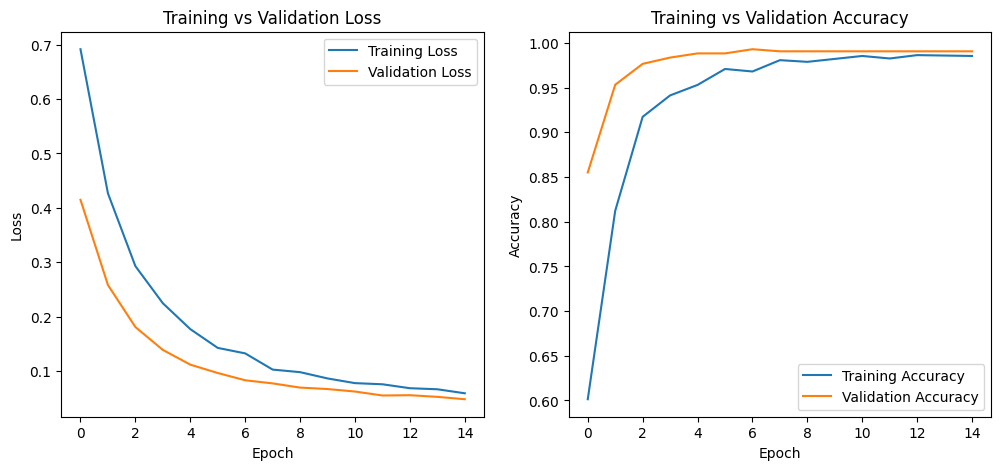

In [ ]:
import matplotlib.pyplot as plt

#To detect overfitting
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

The training and validation loss curves decrease consistently without divergence, and both accuracy curves converge to similar values. This indicates that the model is learning generalizable features rather than overfitting the training data. Early stopping was also implemented to further prevent potential overfitting.

In [ ]:
# Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(test_ds)

# Print the final test accuracy
print("Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 180s 13s/step - accuracy: 1.0000 - loss: 0.0361
Test Accuracy: 1.0


In [ ]:
# Import and mount Google Drive to store the trained model
from google.colab import drive
drive.mount('/content/drive')

# Save the trained model to Google Drive
model.save("/content/drive/MyDrive/photoaging_project/photoaging_model_v1.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import evaluation metrics and NumPy
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Lists to store true labels and predicted labels
y_true = []
y_pred = []

# Generate predictions for the test dataset
for images, labels in test_ds:
    preds = model.predict(images)              # Model predictions
    preds = (preds > 0.5).astype(int)          # Convert probabilities to binary labels

    y_true.extend(labels.numpy())              # Store true labels
    y_pred.extend(preds.flatten())             # Store predicted labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Print classification performance metrics
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[214   0]
 [  0 215]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       214
           1       1.00      1.00      1.00       215

    accuracy                           1.00       429
   macro avg       1.00      1.00      1.00       429
weighted avg       1.00      1.00      1.00       429



In [ ]:
# Iterate through layers of the MobileNetV2 base model
for layer in model.get_layer("mobilenetv2_1.00_224").layers:

    # Print the names of all convolutional layers
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(layer.name)

Conv1
expanded_conv_project
block_1_expand
block_1_project
block_2_expand
block_2_project
block_3_expand
block_3_project
block_4_expand
block_4_project
block_5_expand
block_5_project
block_6_expand
block_6_project
block_7_expand
block_7_project
block_8_expand
block_8_project
block_9_expand
block_9_project
block_10_expand
block_10_project
block_11_expand
block_11_project
block_12_expand
block_12_project
block_13_expand
block_13_project
block_14_expand
block_14_project
block_15_expand
block_15_project
block_16_expand
block_16_project
Conv_1


In [4]:
# Import required libraries for Grad CAM visualization
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Function to generate a Grad CAM heatmap for a given image
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Access the MobileNetV2 base model inside the full model
    base_model = model.get_layer("mobilenetv2_1.00_224")

    # Create a model that outputs the selected convolution layer and predictions
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Record gradients for the predicted class
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    # Compute gradients of the output with respect to feature maps
    grads = tape.gradient(loss, conv_outputs)

    # Average gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the convolutional feature maps by the gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap values between 0 and 1
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()

Positive Test Image


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


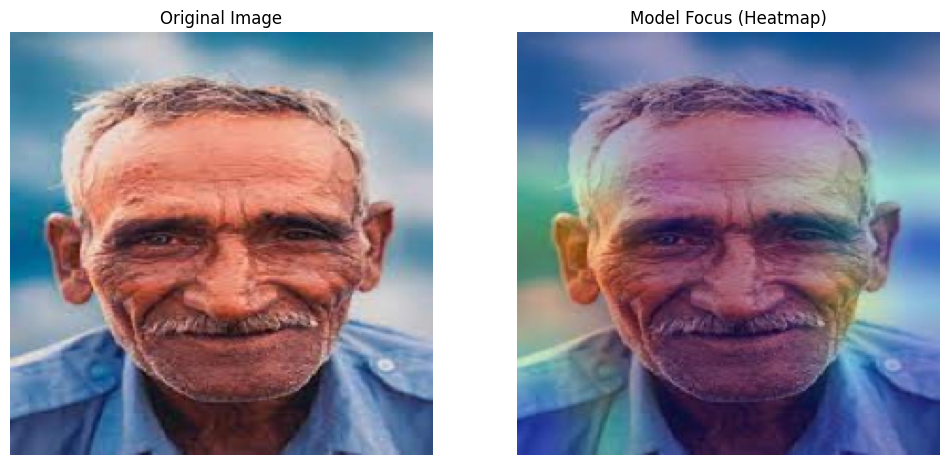

Negative Test Image


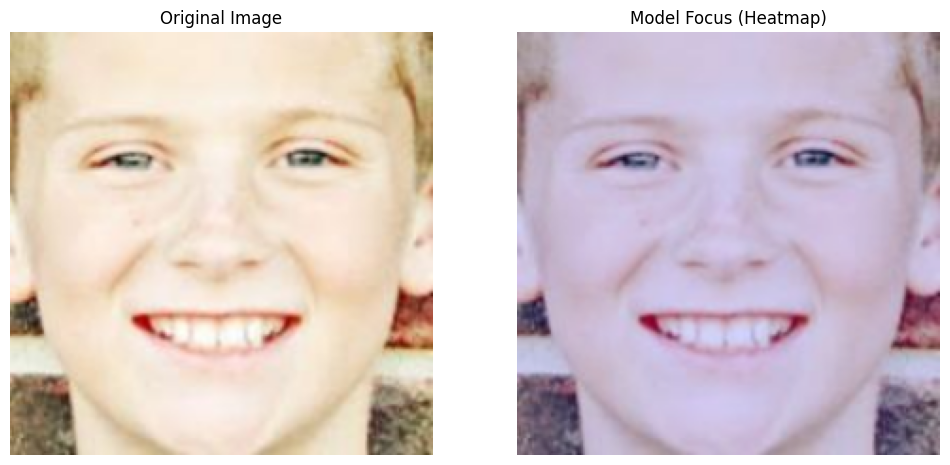

In [6]:
import cv2
import tensorflow as tf # Import tensorflow if not already imported

# --- Load the trained model ---
MODEL_PATH = "/content/drive/MyDrive/photoaging_project/photoaging_model_v1.keras"
model = tf.keras.models.load_model(MODEL_PATH)
# --------------------------------

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # 1. Manually preprocess to match MobileNetV2 requirements
    x = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # 2. Get the specific sub-models
    # We navigate: Global Model -> MobileNetV2 -> Target Layer
    base_model = model.get_layer('mobilenetv2_1.00_224')

    # 3. Create a sub-model strictly for the MobileNet features
    # This avoids the 'Sequential' and 'Augmentation' layers that cause the KeyError
    feature_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=base_model.get_layer(last_conv_layer_name).output
    )

    # 4. Record the operations to calculate gradients
    with tf.GradientTape() as tape:
        # Get conv outputs from the feature extractor
        conv_outputs = feature_extractor(x)
        tape.watch(conv_outputs)

        # Manually complete the rest of the forward pass
        # GlobalAveragePooling -> Dropout -> Dense
        pooling_out = tf.keras.layers.GlobalAveragePooling2D()(conv_outputs)

        # We grab the weights directly from your trained Dense layer
        dense_layer = model.get_layer('dense') # Changed from 'dense_1' to 'dense'
        logits = tf.matmul(pooling_out, dense_layer.kernel) + dense_layer.bias

        # Target the specific class score
        loss = logits[:, 0]

    # 5. Extract gradients of the loss w.r.t. the conv layer output
    grads = tape.gradient(loss, conv_outputs)

    # 6. Compute heatmap math
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Final normalization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    jet_heatmap = np.uint8(jet_heatmap * 255)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Model Focus (Heatmap)")
    plt.axis("off")
    plt.show()

# --- RUN GRAD-CAM ---
# Use one of your positive test images
sample_path = "/content/drive/MyDrive/photoaging_project/data/test/positive/99_jpg.rf.560e3437ad8b16689479d0f4707e44e3.jpg"
img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
print("Positive Test Image")
heatmap = make_gradcam_heatmap(img_array, model, "Conv_1")
display_gradcam(sample_path, heatmap)


sample_path = "/content/drive/MyDrive/photoaging_project/data/test/negative/10_0_0_20170110220557169.jpg.chip.jpg"
img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
print("Negative Test Image")
heatmap = make_gradcam_heatmap(img_array, model, "Conv_1")
display_gradcam(sample_path, heatmap)

Positive Test Image


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


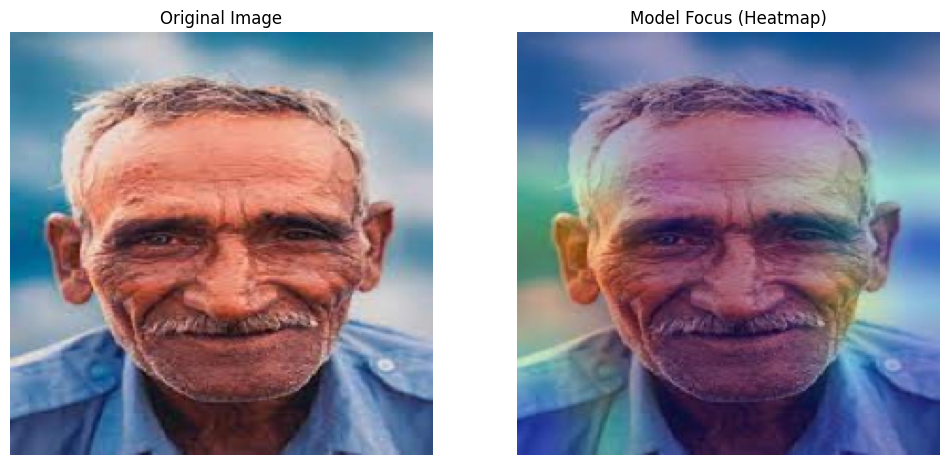

Negative Test Image


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


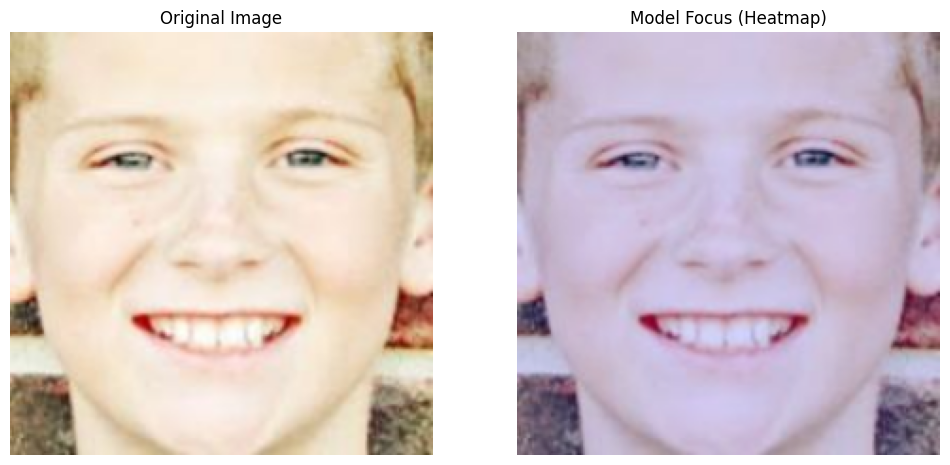

In [7]:
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # 1. Manually preprocess to match MobileNetV2 requirements
    x = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # 2. Get the specific sub-models
    # We navigate: Global Model -> MobileNetV2 -> Target Layer
    base_model = model.get_layer('mobilenetv2_1.00_224')

    # 3. Create a sub-model strictly for the MobileNet features
    # This avoids the 'Sequential' and 'Augmentation' layers that cause the KeyError
    feature_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=base_model.get_layer(last_conv_layer_name).output
    )

    # 4. Record the operations to calculate gradients
    with tf.GradientTape() as tape:
        # Get conv outputs from the feature extractor
        conv_outputs = feature_extractor(x)
        tape.watch(conv_outputs)

        # Manually complete the rest of the forward pass
        # GlobalAveragePooling -> Dropout -> Dense
        pooling_out = tf.keras.layers.GlobalAveragePooling2D()(conv_outputs)

        # We grab the weights directly from your trained Dense layer
        dense_layer = model.get_layer('dense') # Changed from 'dense_1' to 'dense'
        logits = tf.matmul(pooling_out, dense_layer.kernel) + dense_layer.bias

        # Target the specific class score
        loss = logits[:, 0]

    # 5. Extract gradients of the loss w.r.t. the conv layer output
    grads = tape.gradient(loss, conv_outputs)

    # 6. Compute heatmap math
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Final normalization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    jet_heatmap = np.uint8(jet_heatmap * 255)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Model Focus (Heatmap)")
    plt.axis("off")
    plt.show()

# --- RUN GRAD-CAM ---
# Use one of your positive test images
sample_path = "/content/drive/MyDrive/photoaging_project/data/test/positive/99_jpg.rf.560e3437ad8b16689479d0f4707e44e3.jpg"
img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
print("Positive Test Image")
heatmap = make_gradcam_heatmap(img_array, model, "Conv_1")
display_gradcam(sample_path, heatmap)


sample_path = "/content/drive/MyDrive/photoaging_project/data/test/negative/10_0_0_20170110220557169.jpg.chip.jpg"
img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
print("Negative Test Image")
heatmap = make_gradcam_heatmap(img_array, model, "Conv_1")
display_gradcam(sample_path, heatmap)

In [8]:
# -----------------------------------------
# LOAD AIR POLLUTION DATASET
# -----------------------------------------
# Import TensorFlow for building and training the model
import tensorflow as tf
import pandas as pd

AQI_PATH = "/content/drive/MyDrive/photoaging_project/AQI and Lat Long of Countries.csv"

aqi_df = pd.read_csv(AQI_PATH)

# Keep only relevant columns
aqi_df = aqi_df[["City","Country","PM2.5 AQI Value"]]

# Rename for simplicity
aqi_df.columns = ["city","country","pm25_aqi"]

# Remove missing values
aqi_df = aqi_df.dropna()

# Convert to lowercase for easier matching
aqi_df["city"] = aqi_df["city"].str.lower()
aqi_df["country"] = aqi_df["country"].str.lower()

# Average duplicate monitoring stations
aqi_df = aqi_df.groupby(["city","country"], as_index=False).mean()

print("Pollution dataset loaded.")
print("Total cities:", len(aqi_df))

Pollution dataset loaded.
Total cities: 13956


In [9]:
import difflib

def get_city_pm25(city_name):

    city_name = city_name.strip().lower()

    # Find matches
    matches = aqi_df[aqi_df["city"] == city_name]

    if len(matches) == 1:
        return float(matches.iloc[0]["pm25_aqi"])

    if len(matches) > 1:
        print("\nMultiple cities found with that name:")

        for i, row in matches.iterrows():
            print(f"{i}: {row['city'].title()}, {row['country'].title()}")

        selection = int(input("Select the correct city number: "))
        return float(aqi_df.loc[selection]["pm25_aqi"])

    # If city not found → suggest closest cities
    print("\nCity not found.")

    suggestions = difflib.get_close_matches(city_name, aqi_df["city"].unique(), n=5)

    if suggestions:
        print("Did you mean one of these?")
        for s in suggestions:
            print("-", s.title())

    return None

    # -----------------------------------------
# CONVERT AQI TO POLLUTION RISK SCORE
# -----------------------------------------

def normalize_pm25_aqi(aqi):

    if aqi is None:
        return 0.6

    if aqi <= 50:
        return 0.2

    elif aqi <= 100:
        return 0.4

    elif aqi <= 150:
        return 0.6

    elif aqi <= 200:
        return 0.8

    else:
        return 1.0

In [10]:
# ============================================================
# PHOTOAGING BURDEN INDEX (PBI)
# Combines CNN visible photoaging prediction with lifestyle exposure factors
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files
from PIL import Image
import io

# ------------------------------------------------------------
# LOAD TRAINED MODEL
# ------------------------------------------------------------

MODEL_PATH = "/content/drive/MyDrive/photoaging_project/photoaging_model_v1.keras"
model = tf.keras.models.load_model(MODEL_PATH)

IMG_SIZE = (224, 224)
BASE_MODEL_NAME = "mobilenetv2_1.00_224"
LAST_CONV_LAYER_NAME = "Conv_1"

# ------------------------------------------------------------
# IMAGE UPLOAD
# ------------------------------------------------------------

print("\nUpload a clear frontal face image.")
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
img_pil = Image.open(io.BytesIO(uploaded[image_name])).convert("RGB")
img_resized = img_pil.resize(IMG_SIZE)

img_array = np.array(img_resized).astype(np.float32)
img_array = np.expand_dims(img_array, axis=0)

# ------------------------------------------------------------
# CNN VISIBLE PHOTOAGING SCORE
# ------------------------------------------------------------

x_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
prediction = model.predict(x_preprocessed, verbose=0)
P_vis = float(prediction[0, 0])

# ------------------------------------------------------------
# LIFESTYLE QUESTIONNAIRE
# ------------------------------------------------------------

print("\n=== Lifestyle Questionnaire ===")

hours_outdoors = float(
    input("How many hours do you on average spend outdoors per day? (0–8): ")
)

cigs_per_day = int(
    input("Do you smoke cigarettes? If yes, how many per day? (0 if none): ")
)

# --- Pollution input with validation ---
pm25_value = None

while pm25_value is None:

    city = input("Which city do you live in most of the time? ")
    pm25_value = get_city_pm25(city)

sunscreen_use = input(
    "Do you apply sunscreen daily? (yes/no): "
).strip().lower()

# ------------------------------------------------------------
# NORMALIZATION FUNCTIONS
# ------------------------------------------------------------

def clamp01(x):
    return float(max(0.0, min(1.0, x)))

# UV exposure proxy
U = clamp01(hours_outdoors / 6.0)

# Smoking exposure proxy
S = clamp01(cigs_per_day / 20.0)

# Pollution exposure using AQI dataset
P = normalize_pm25_aqi(pm25_value)

print("\nPollution Data:")
print("City PM2.5 AQI:", pm25_value)
print("Pollution Risk Score:", round(P, 3))

# Sunscreen protection modifier
C_protection = {"yes": 1.0, "no": 0.0}.get(sunscreen_use, 0.0)

# ------------------------------------------------------------
# EXPOSURE RISK SCORE
# ------------------------------------------------------------

W_UV = 0.70
W_SMOKE = 0.15
W_POLL = 0.10
W_SUNSCREEN = 0.05

R_exp = (
    W_UV * U +
    W_SMOKE * S +
    W_POLL * P +
    W_SUNSCREEN * (1 - C_protection)
)

R_exp = clamp01(R_exp)

# ------------------------------------------------------------
# FINAL PHOTOAGING BURDEN INDEX
# ------------------------------------------------------------

ALPHA = 0.80

PBI = clamp01(
    ALPHA * P_vis +
    (1 - ALPHA) * R_exp
)

# ------------------------------------------------------------
# CATEGORY INTERPRETATION
# ------------------------------------------------------------

def category(score):

    if score < 0.33:
        return "Low"

    elif score < 0.66:
        return "Moderate"

    else:
        return "High"

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n=== Photoaging Burden Results ===")

print("Visible Photoaging Probability:", round(P_vis, 4))
print("Exposure Risk Component:", round(R_exp, 4))
print("Final Photoaging Burden Index:", round(PBI, 4))
print("Severity Category:", category(PBI))

print("\nNormalized Factors:")
print("UV:", round(U, 3))
print("Smoking:", round(S, 3))
print("Pollution:", round(P, 3))
print("Sunscreen Protection:", round(C_protection, 3))


Upload a clear frontal face image.


Saving MyImage.jpg to MyImage.jpg

=== Lifestyle Questionnaire ===
How many hours do you on average spend outdoors per day? (0–8): 2
Do you smoke cigarettes? If yes, how many per day? (0 if none): 0
Which city do you live in most of the time? London
Do you apply sunscreen daily? (yes/no): yes

Pollution Data:
City PM2.5 AQI: 40.0
Pollution Risk Score: 0.2

=== Photoaging Burden Results ===
Visible Photoaging Probability: 0.5887
Exposure Risk Component: 0.2533
Final Photoaging Burden Index: 0.5216
Severity Category: Moderate

Normalized Factors:
UV: 0.333
Smoking: 0.0
Pollution: 0.2
Sunscreen Protection: 1.0
